#THE EDA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore') 
import gc

In [2]:
file = pd.read_csv('heart.csv')
file1 = file.copy()

In [3]:
file.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
file.info()
 


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
file = file.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', file.shape)

Shape after removing duplicates: (918, 12)


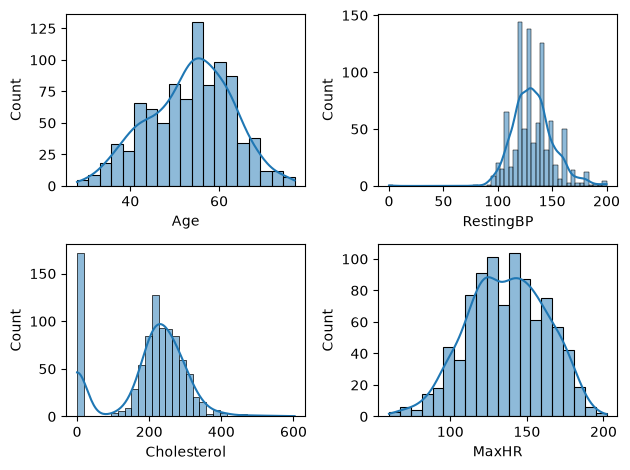

In [6]:
def plot(var,num):
  plt.subplot(2,2,num)
  sns.histplot(file[var],kde=True)
  plt.tight_layout()
plot('Age',1)
plot('RestingBP',2)
plot('Cholesterol',3)
plot('MaxHR',4)

In [7]:
new_mean = file.loc[file['Cholesterol'] != 0, 'Cholesterol'].mean()
print(round(new_mean, 2))

244.64


In [8]:
file['Cholesterol'] = file['Cholesterol'].astype(float)
file['Cholesterol'] = file['Cholesterol'].replace(0, round(new_mean, 2))

In [9]:
file['RestingBP'] = file['RestingBP'].astype(float)
resting_bp_mean = file.loc[file['RestingBP'] != 0, 'RestingBP'].mean()
file.loc[file['RestingBP'] == 0, 'RestingBP'] = round(resting_bp_mean, 2)

#preprocessing


In [10]:
file['Cholesterol'].value_counts()


Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
211.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [11]:
file['MaxHR'].value_counts()

MaxHR
150    43
140    41
120    36
130    33
160    25
       ..
192     1
195     1
194     1
187     1
202     1
Name: count, Length: 119, dtype: int64

In [12]:
file['RestingBP'].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

In [13]:
file['Age'].value_counts()

Age
54    51
58    42
55    41
56    38
57    38
52    36
51    35
59    35
62    35
53    33
60    32
48    31
61    31
63    30
50    25
43    24
41    24
46    24
64    22
49    21
65    21
44    19
47    19
45    18
42    18
38    16
39    15
67    15
40    13
66    13
69    13
37    11
35    11
68    10
34     7
74     7
70     7
36     6
32     5
71     5
72     4
29     3
75     3
31     2
33     2
77     2
76     2
28     1
30     1
73     1
Name: count, dtype: int64

In [14]:
file['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [15]:
file['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [16]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 86.2 KB


In [17]:
file['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [18]:
file =pd.get_dummies(file,columns=['ChestPainType'],drop_first=True,dtype=int)

In [19]:
file['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [20]:
file=pd.get_dummies(file,columns=['ExerciseAngina'],drop_first=True,dtype=int)

In [21]:
file=pd.get_dummies(file,columns=['RestingECG'],drop_first=True,dtype=int)

In [22]:
file.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_Y,RestingECG_Normal,RestingECG_ST
0,40,M,140.0,289.0,0,172,0.0,Up,0,1,0,0,0,1,0
1,49,F,160.0,180.0,0,156,1.0,Flat,1,0,1,0,0,1,0
2,37,M,130.0,283.0,0,98,0.0,Up,0,1,0,0,0,0,1
3,48,F,138.0,214.0,0,108,1.5,Flat,1,0,0,0,1,1,0
4,54,M,150.0,195.0,0,122,0.0,Up,0,0,1,0,0,1,0


In [55]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   ChestPainType_ATA  918 non-null    int64  
 8   ChestPainType_NAP  918 non-null    int64  
 9   ChestPainType_TA   918 non-null    int64  
 10  ExerciseAngina_Y   918 non-null    int64  
 11  RestingECG_Normal  918 non-null    int64  
 12  RestingECG_ST      918 non-null    int64  
 13  ST_Slope_Flat      918 non-null    int64  
 14  ST_Slope_Up        918 non-null    int64  
 15  Sex_M              918 non-null    int64  
dtypes: float64(1), int64(15)
memory usage

In [24]:
file = pd.get_dummies(file, columns=['ST_Slope'], drop_first=True, dtype=int)

In [25]:
file.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_Y,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,M,140.0,289.0,0,172,0.0,0,1,0,0,0,1,0,0,1
1,49,F,160.0,180.0,0,156,1.0,1,0,1,0,0,1,0,1,0
2,37,M,130.0,283.0,0,98,0.0,0,1,0,0,0,0,1,0,1
3,48,F,138.0,214.0,0,108,1.5,1,0,0,0,1,1,0,1,0
4,54,M,150.0,195.0,0,122,0.0,0,0,1,0,0,1,0,0,1


In [26]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    str    
 2   RestingBP          918 non-null    float64
 3   Cholesterol        918 non-null    float64
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   Oldpeak            918 non-null    float64
 7   HeartDisease       918 non-null    int64  
 8   ChestPainType_ATA  918 non-null    int64  
 9   ChestPainType_NAP  918 non-null    int64  
 10  ChestPainType_TA   918 non-null    int64  
 11  ExerciseAngina_Y   918 non-null    int64  
 12  RestingECG_Normal  918 non-null    int64  
 13  RestingECG_ST      918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(3), int64(12), str(1)
memo

In [27]:
file = pd.get_dummies(file, columns=['Sex'], drop_first=True, dtype=int)

In [28]:
file['Oldpeak'].value_counts()

Oldpeak
 0.0    368
 1.0     86
 2.0     76
 1.5     53
 3.0     28
 1.2     26
 0.2     22
 0.5     19
 1.4     18
 1.8     17
 2.5     16
 0.8     16
 1.6     16
 0.1     14
 0.6     14
 0.4     11
 0.3     11
 4.0      8
 0.7      7
 1.3      7
 2.6      7
 2.8      7
 1.1      7
 1.9      7
 1.7      6
 2.2      5
 0.9      4
 2.4      4
 3.6      4
 3.4      3
 2.1      2
-0.1      2
-1.0      2
-0.5      2
 3.5      2
 2.3      2
 4.2      2
 3.2      2
 5.0      1
-0.9      1
-2.6      1
-1.5      1
-1.1      1
-0.7      1
-0.8      1
 3.7      1
-2.0      1
 3.1      1
 5.6      1
 3.8      1
 2.9      1
 6.2      1
 4.4      1
Name: count, dtype: int64

In [29]:
del file1
gc.collect()

15221

In [30]:
file = file.astype({
    'Cholesterol': int,
    'RestingBP': int
})

In [31]:
from scipy.stats import chi2_contingency

alpha = 0.10
features = [
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'ExerciseAngina_Y',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ST_Slope_Flat',
    'ST_Slope_Up',
    'Sex_M'
]

results = {}
for feature in features:
    contingency_table = pd.crosstab(file[feature], file['HeartDisease'])
    chi2_stat, p_val, df, expected = chi2_contingency(contingency_table)
    decision = 'keep feature (null hypothesis rejected)' if p_val < alpha else 'discard feature (null hypothesis accepted)'
    results[feature] = {
        'chi2_stat': chi2_stat,
        'p_value': p_val,
        'degree_of_freedom': df,
        'decision': decision
    }

results = pd.DataFrame(results).T
print(results)

                    chi2_stat   p_value degree_of_freedom  \
ChestPainType_ATA  146.236323       0.0                 1   
ChestPainType_NAP   40.608711       0.0                 1   
ChestPainType_TA     2.273802  0.131577                 1   
ExerciseAngina_Y   222.259383       0.0                 1   
RestingECG_Normal    7.327532  0.006791                 1   
RestingECG_ST        9.135266  0.002507                 1   
ST_Slope_Flat      279.659914       0.0                 1   
ST_Slope_Up        352.823905       0.0                 1   
Sex_M               84.145101       0.0                 1   

                                                     decision  
ChestPainType_ATA     keep feature (null hypothesis rejected)  
ChestPainType_NAP     keep feature (null hypothesis rejected)  
ChestPainType_TA   discard feature (null hypothesis accepted)  
ExerciseAngina_Y      keep feature (null hypothesis rejected)  
RestingECG_Normal     keep feature (null hypothesis rejected)  
Resti

In [32]:
selected_features = [
    'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'ExerciseAngina_Y', 'RestingECG_Normal', 'RestingECG_ST',
    'ST_Slope_Flat', 'ST_Slope_Up', 'Sex_M', 'HeartDisease'
]

cleaned = file[selected_features].copy()
cleaned.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_Y,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Sex_M,HeartDisease
0,40,140,289,0,172,0.0,1,0,0,0,1,0,0,1,1,0
1,49,160,180,0,156,1.0,0,1,0,0,1,0,1,0,0,1
2,37,130,283,0,98,0.0,1,0,0,0,0,1,0,1,1,0
3,48,138,214,0,108,1.5,0,0,0,1,1,0,1,0,0,1
4,54,150,195,0,122,0.0,0,1,0,0,1,0,0,1,1,0


In [33]:
from scipy.stats import pearsonr

numeric_features = [
    'Age', 'RestingBP', 'Cholesterol',
    'FastingBS', 'MaxHR', 'Oldpeak'
]

correlation = {
    feature: pearsonr(cleaned[feature], cleaned['HeartDisease'])[0]
    for feature in numeric_features
}

In [34]:
correlation = pd.DataFrame(list(correlation.items()), columns=['feature', 'correlation'])

In [35]:
print(correlation)

       feature  correlation
0          Age     0.282039
1    RestingBP     0.117909
2  Cholesterol     0.092586
3    FastingBS     0.267291
4        MaxHR    -0.400421
5      Oldpeak     0.403951


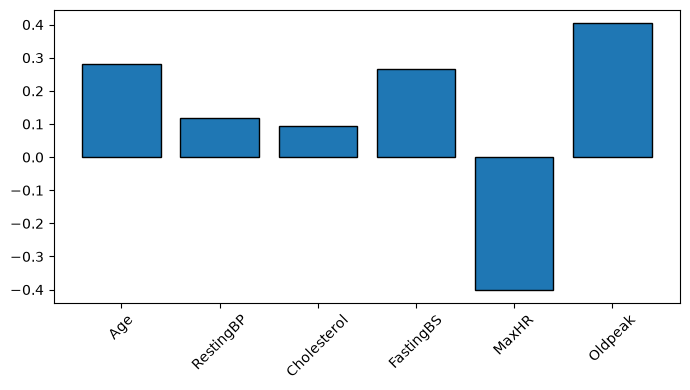

In [36]:
plt.figure(figsize=(7, 4))
plt.bar(correlation['feature'], correlation['correlation'], edgecolor='black')
plt.xticks(rotation=45)
plt.tight_layout()

In [37]:
print('done')

done


In [38]:
X = cleaned.drop('HeartDisease',axis=1)
y= cleaned['HeartDisease']

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_test)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  \
356   46        115          244          0    113      1.5   
763   58        132          224          0    173      3.2   
817   60        125          258          0    141      2.8   
735   49        120          188          0    139      2.0   
892   39        138          220          0    152      0.0   
..   ...        ...          ...        ...    ...      ...   
52    45        140          224          1    122      0.0   
752   56        125          249          1    144      1.2   
492   49        130          244          0    145      3.0   
622   59        110          239          0    142      1.2   
316   57        105          244          1    148      0.3   

     ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  ExerciseAngina_Y  \
356                  0                  0                 0                 1   
763                  0                  1                 0                 0   


In [44]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [52]:
y_pred=logreg.predict(X_test_scaled)
y_pred_proba=logreg.predict_proba(X_test_scaled)[:,1]

In [53]:
from sklearn import metrics
print("the acurracy is ",metrics.accuracy_score(y_test,y_pred))
print("the F1 score is ",metrics.f1_score(y_test,y_pred))
print("the precision_score is ",metrics.precision_score(y_test,y_pred))
print("the recall_score is ",metrics.recall_score(y_test,y_pred))
print("the roc_auc_score is ",metrics.roc_auc_score(y_test,y_pred_proba))

the acurracy is  0.8913043478260869
the F1 score is  0.9029126213592233
the precision_score is  0.8942307692307693
the recall_score is  0.9117647058823529
the roc_auc_score is  0.9330463892874222


In [54]:
cm = metrics.confusion_matrix(y_test,y_pred)
print(cm)

[[71 11]
 [ 9 93]]


In [65]:
nod = np.linspace(0.10,0.50,num=15,endpoint=True,retstep=False)
for threshold in nod:
  y_pred_threshold=(y_pred_proba>=threshold).astype(int)
  recall=metrics.recall_score(y_test,y_pred_threshold)
  accuracy=metrics.accuracy_score(y_test,y_pred_threshold)
  precision = metrics.precision_score(y_test,y_pred_threshold)
  f1 = metrics.f1_score(y_test,y_pred_threshold)
  print(
    f"threshhold is: {threshold:1f}|"
   f"accuracy is : {accuracy:.2f}|"
    f"recall: {recall:.3f}|"
    f"precision: {precision:.3f}|"
    f"F1 is : {f1:3f}"
  )


threshhold is: 0.100000|accuracy is : 0.77|recall: 0.961|precision: 0.721|F1 is : 0.823529
threshhold is: 0.128571|accuracy is : 0.80|recall: 0.951|precision: 0.752|F1 is : 0.839827
threshhold is: 0.157143|accuracy is : 0.82|recall: 0.941|precision: 0.780|F1 is : 0.853333
threshhold is: 0.185714|accuracy is : 0.83|recall: 0.941|precision: 0.787|F1 is : 0.857143
threshhold is: 0.214286|accuracy is : 0.83|recall: 0.941|precision: 0.787|F1 is : 0.857143
threshhold is: 0.242857|accuracy is : 0.84|recall: 0.941|precision: 0.807|F1 is : 0.868778
threshhold is: 0.271429|accuracy is : 0.85|recall: 0.941|precision: 0.814|F1 is : 0.872727
threshhold is: 0.300000|accuracy is : 0.86|recall: 0.941|precision: 0.828|F1 is : 0.880734
threshhold is: 0.328571|accuracy is : 0.86|recall: 0.941|precision: 0.835|F1 is : 0.884793
threshhold is: 0.357143|accuracy is : 0.88|recall: 0.941|precision: 0.850|F1 is : 0.893023
threshhold is: 0.385714|accuracy is : 0.88|recall: 0.941|precision: 0.850|F1 is : 0.893023

In [68]:
from sklearn.pipeline  import Pipeline
pipeline = Pipeline([
  ('scaler',StandardScaler()),
  ('logreg',LogisticRegression())
])

In [69]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
  pipeline,
  X_train,
  y_train,
  cv=10,
  scoring='recall'

)

In [70]:
print("the mean of the scores is :", scores.mean())
print("the std of the scores is : ",scores.std())

the mean of the scores is : 0.869390243902439
the std of the scores is :  0.04432285155020985


In [71]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

for metric in ["test_accuracy", "test_precision", "test_recall",
               "test_f1", "test_roc_auc"]:

    print(metric)
    print("Mean:", results[metric].mean())
    print("Std :", results[metric].std())
    print()

test_accuracy
Mean: 0.8487186655484111
Std : 0.02635632293454326

test_precision
Mean: 0.8596266090726127
Std : 0.028947054065996184

test_recall
Mean: 0.8693164709424872
Std : 0.03017878641385206

test_f1
Mean: 0.8640390239546358
Std : 0.023063087468040627

test_roc_auc
Mean: 0.914986863984154
Std : 0.035763118476174235



In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logreg__C":[0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

In [75]:
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)

Best parameters: {'logreg__C': 0.01}
Best CV recall: 0.8940078289671785
